In [1]:
# imports time series
import pandas as pd
import numpy as np

# plots
import matplotlib.pyplot as plt
%matplotlib inline

# para calcular métricas del modelo
from sklearn.metrics import mean_squared_error

# misc
import os
import time
import itertools
import warnings
warnings.filterwarnings("ignore")

# apartado ts
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing, Holt

from prophet import Prophet

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_PATH = '/content/drive/MyDrive/A tfm/data'

In [4]:
df_sales = pd.read_csv(DATA_PATH + '/sales.csv')

In [5]:
df_sales

,Unnamed: 0,pk_sale,cid,month_sale,product_ID,net_margin,z_log_net_margin,z_target_margin_level
0,0,6666,33620,2018-05-01,2335,952.9,6.859510,3
1,1,6667,35063,2018-06-01,2335,1625.2,7.393386,3
2,2,6668,37299,2018-02-01,2335,1279.7,7.154381,3
3,3,6669,39997,2018-02-01,2335,1511.9,7.321122,3
4,4,6670,44012,2018-02-01,2335,1680.3,7.426728,3
...,...,...,...,...,...,...,...,...
240768,240768,247434,1553456,2019-05-01,4657,56.7,4.037774,1
240769,240769,247435,1553541,2019-05-01,4657,66.5,4.197202,2
240770,240770,247436,1553559,2019-05-01,4657,73.0,4.290459,2
240771,240771,247437,1553565,2019-05-01,4657,82.3,4.410371,3


In [6]:
df_products = pd.read_csv(DATA_PATH + '/product_description.csv')

In [7]:
#crear logaritmica del margen
df_sales['z_log_net_margin'] = np.log(df_sales['net_margin'])




In [8]:
#crear cluster de margen, bajo = 1, medio = 2, alto = 3
df_sales['z_target_margin_level'] = pd.qcut(
    df_sales['net_margin'], q=3, labels=[1, 2, 3]
)
df_sales['z_target_margin_level'] = df_sales['z_target_margin_level'].astype(int)

In [9]:
df_sales

,Unnamed: 0,pk_sale,cid,month_sale,product_ID,net_margin,z_log_net_margin,z_target_margin_level
0,0,6666,33620,2018-05-01,2335,952.9,6.859510,3
1,1,6667,35063,2018-06-01,2335,1625.2,7.393386,3
2,2,6668,37299,2018-02-01,2335,1279.7,7.154381,3
3,3,6669,39997,2018-02-01,2335,1511.9,7.321122,3
4,4,6670,44012,2018-02-01,2335,1680.3,7.426728,3
...,...,...,...,...,...,...,...,...
240768,240768,247434,1553456,2019-05-01,4657,56.7,4.037774,1
240769,240769,247435,1553541,2019-05-01,4657,66.5,4.197202,2
240770,240770,247436,1553559,2019-05-01,4657,73.0,4.290459,2
240771,240771,247437,1553565,2019-05-01,4657,82.3,4.410371,3


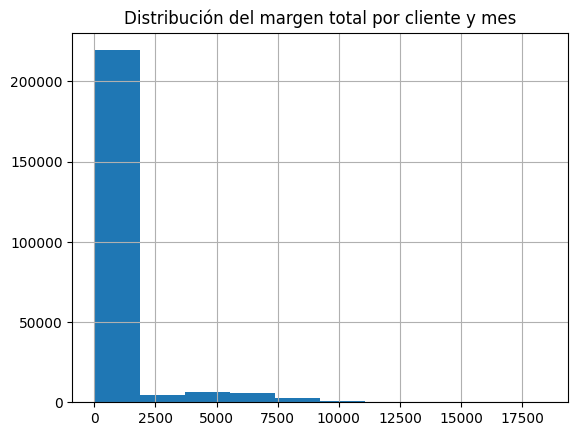

In [10]:
df_sales['net_margin'].hist(bins=10)
plt.title("Distribución del margen total por cliente y mes")
plt.show()

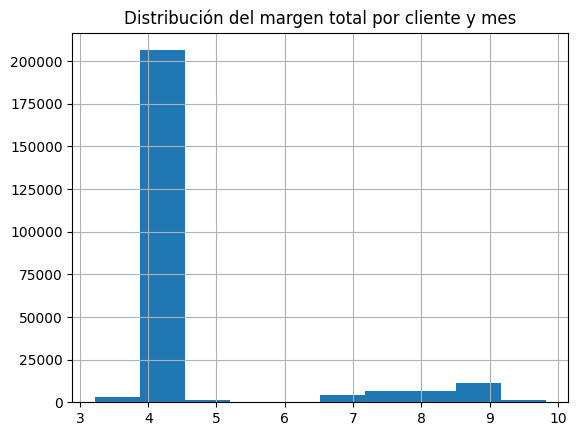

In [11]:
df_sales['z_log_net_margin'].hist(bins=10)
plt.title("Distribución del margen total por cliente y mes")
plt.show()

In [12]:
#Dashboard - month sale, nb de ventas, máximo margen y número de clientes únicos
sales_per_month = df_sales.groupby('month_sale').agg(
    sales_count=('month_sale', 'size'),
    max_net_margin=('net_margin', 'max'),
    unique_cids=('cid', 'nunique')
).reset_index()
display(sales_per_month)

,month_sale,sales_count,max_net_margin,unique_cids
0,2018-02-01,15182,18466.4,11992
1,2018-03-01,11668,15170.6,9405
2,2018-04-01,9962,16612.4,7974
3,2018-05-01,9558,15869.5,7685
4,2018-06-01,11558,14768.8,9321
5,2018-07-01,20602,17615.6,17644
6,2018-08-01,21054,15263.8,18740
7,2018-09-01,24488,15457.8,22452
8,2018-10-01,27693,16219.3,25167
9,2018-11-01,19155,16589.3,16441


In [13]:
#número de clientes por product_ID
df_sales.groupby('product_ID').agg({'cid':'count'}).sort_values('cid', ascending=False).head(100)

,cid
product_ID,
4657,117435
3819,38840
1364,19369
2234,18750
2235,18110
8871,12323
2312,5206
2335,4441
2336,4227


In [14]:
#Máximo margen neto por producto
display(df_sales.groupby('product_ID')['net_margin'].max().sort_values(ascending=False))

,net_margin
product_ID,
1364,18466.4
4033,5360.5
9001,4135.9
2336,4006.0
2335,3807.8
2673,3538.5
1119,3403.2
4657,115.5
2235,111.8


In [15]:
#máximo margen neto por cliente

display(df_sales.groupby('cid')['net_margin'].max().sort_values(ascending=False))

,net_margin
cid,
1330238,18466.4
1528334,17699.0
1392613,17615.6
1208380,17133.2
1541245,17131.4
...,...
1427606,32.5
1478462,32.2
1483485,31.4


In [16]:
#Número de margenes por producto

display(df_sales.groupby('product_ID')['net_margin'].nunique().reset_index().rename(columns={'net_margin': 'unique_margin_count'}))

,product_ID,unique_margin_count
0,1119,862
1,1364,17069
2,2234,620
3,2235,623
4,2312,293
5,2335,3874
6,2336,3704
7,2673,1100
8,3819,350
9,4033,10


In [18]:
df_sales.to_csv(DATA_PATH + '/sales_pbi.csv', index=False)